# Comparison of term-structure models

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from copy import copy

from quantpy.math.curve import TermStructureABC
from quantpy.math.curve import Svensson
from quantpy.math.curve import Anderson
from quantpy.math.curve import MultidynamicModel

plt.style.use('seaborn-v0_8-whitegrid')
example_root = Path(os.path.abspath(""))

## Data loading

In [2]:
svensson_color     = "royalblue"
anderson_color     = "indianred"
multidynamic_color = "forestgreen"
data_color         = "dimgrey"

In [3]:
yields_df  = pd.read_csv(example_root / "data" / f"fi_yields_2026-02-27.csv")
yields     = yields_df["ZeroYield"].to_numpy()
maturities = yields_df["TimeToMaturity"].to_numpy()

## Basic curve fitting

In [4]:
svensson_model     = Svensson(yields, maturities, init_params=[0.2, 10, 0.01, 0.0001, 0.01, 0.1], method="dogbox", ftol=1e-8, xtol=1e-8, gtol=1e-8, max_nfev=10_000)
anderson_model     = Anderson(yields, maturities, (4.6, -15, 2), knots = np.linspace(maturities.min(), maturities.max(), len(maturities) // 2 + 1))
multidynamic_model = MultidynamicModel(yields, maturities, init_params=[0.4, 0.04, 0.02, 0.02, 0.01, 0.005], method="dogbox", ftol=1e-8, xtol=1e-8, gtol=1e-8, max_nfev=100_000)

/home/kasper/GIT/quantpy/quantpy/math/curve/Anderson.py:128: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  L_ij = quad(func, m_0, m_n, epsabs=1e-6, epsrel=1e-6)
/home/kasper/GIT/quantpy/quantpy/math/curve/Anderson.py:128: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  L_ij = quad(func, m_0, m_n, epsabs=1e-6, epsrel=1e-6)


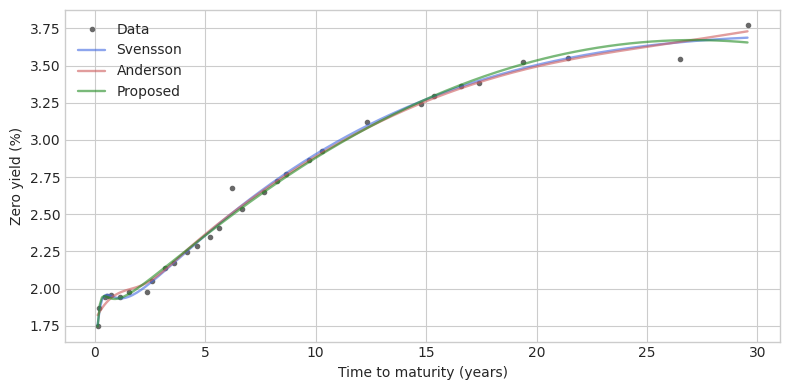

In [5]:
tt = np.linspace(maturities.min(), maturities.max(), 300)

fig = plt.figure(figsize=(8, 4))

plt.plot(maturities, yields * 100, linestyle='None', marker='.', color=data_color, label="Data")
plt.plot(tt, svensson_model(tt) * 100, linestyle='-', color=svensson_color, label="Svensson", alpha=0.6, linewidth=1.7)
plt.plot(tt, anderson_model(tt) * 100, linestyle='-', color=anderson_color, label="Anderson", alpha=0.6, linewidth=1.7)
plt.plot(tt, multidynamic_model(tt) * 100, linestyle='-', color=multidynamic_color, label="Proposed", alpha=0.6, linewidth=1.7)

plt.xlabel("Time to maturity (years)")
plt.ylabel("Zero yield (%)")

plt.legend()
fig.tight_layout()
plt.show()

## Shift in the long end

In [ ]:
shift_yields = copy(yields)
shift_yields[-1] = yields[-1] - 0.003, knots ,,,   , 

In [7]:
shifted_svensson_model     = Svensson(shift_yields, maturities, init_params=[0.2, 10, 0.01, 0.0001, 0.01, 0.1], method="dogbox", ftol=1e-8, xtol=1e-8, gtol=1e-8, max_nfev=10_000)
shifted_anderson_model     = Anderson(shift_yields, maturities, (4.6, -15, 2), knots = np.linspace(maturities.min(), maturities.max(), len(maturities) // 2 + 1))
shifted_multidynamic_model = MultidynamicModel(shift_yields, maturities, init_params=[0.4, 0.04, 0.02, 0.02, 0.01, 0.005], method="dogbox", ftol=1e-8, xtol=1e-8, gtol=1e-8, max_nfev=100_000)

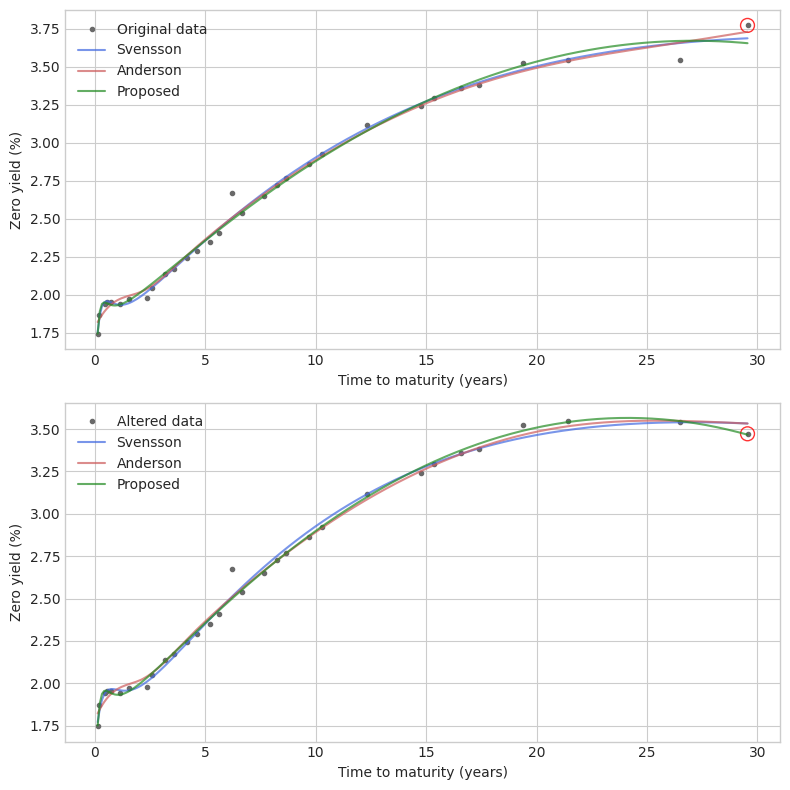

In [8]:
tt = np.linspace(maturities.min(), maturities.max(), 300)

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 8))

axs[0].plot(maturities, yields * 100, linestyle='None', marker='.', color=data_color, label="Original data")
axs[0].scatter(maturities[-1], yields[-1] * 100, [100], marker='o', facecolor='None', edgecolor='red', alpha=0.8)
axs[0].plot(tt, svensson_model(tt) * 100, linestyle='-', color=svensson_color, label="Svensson", alpha=0.7, linewidth=1.5)
axs[0].plot(tt, anderson_model(tt) * 100, linestyle='-', color=anderson_color, label="Anderson", alpha=0.7, linewidth=1.5)
axs[0].plot(tt, multidynamic_model(tt) * 100, linestyle='-', color=multidynamic_color, label="Proposed", alpha=0.7, linewidth=1.5)

axs[0].set_xlabel("Time to maturity (years)")
axs[0].set_ylabel("Zero yield (%)")
axs[0].legend()

axs[1].plot(maturities, shift_yields * 100, linestyle='None', marker='.', color=data_color, label="Altered data")
axs[1].scatter(maturities[-1], shift_yields[-1] * 100, [100], marker='o', facecolor='None', edgecolor='red', alpha=0.8)
axs[1].plot(tt, shifted_svensson_model(tt) * 100, linestyle='-', color=svensson_color, label="Svensson", alpha=0.7, linewidth=1.5)
axs[1].plot(tt, shifted_anderson_model(tt) * 100, linestyle='-', color=anderson_color, label="Anderson", alpha=0.7, linewidth=1.5)
axs[1].plot(tt, shifted_multidynamic_model(tt) * 100, linestyle='-', color=multidynamic_color, label="Proposed", alpha=0.7, linewidth=1.5)

axs[1].set_xlabel("Time to maturity (years)")
axs[1].set_ylabel("Zero yield (%)")
axs[1].legend()

fig.tight_layout()
fig.savefig(example_root / "figures" / "06_shifted_long_end.pdf")
plt.show()

## Goodness of fit - leave one out cross-validation

In [9]:
from typing import List, Dict, Tuple


def discount(rate: float, maturity: float) -> float:
  """Continuously discounting of a 1 EUR bond"""
  return np.exp(-rate * maturity)


def leave_one_out_cv(maturities: np.ndarray[float], yields: np.ndarray[float], models: List[TermStructureABC], model_kwargs: List[Dict[any, any]]) -> List[Tuple[float, float]]:
  """Leave one out cross validation of the models. Always retains the endpoints. Returns a list of tuples of form (mean, std) for the residual errors."""
  leave_one_out_residuals = [[] for _ in range(len(models))]
  
  for i in range(1, len(maturities) - 1):
    train_maturities = np.array([m for j, m in enumerate(maturities) if j != i])
    train_yields     = np.array([y for j, y in enumerate(yields) if j != i])
    
    trained_models = [model(train_yields, train_maturities, **model_kwargs[j]) for j, model in enumerate(models)]
    
    for j, model in enumerate(trained_models):
      leave_one_out_residuals[j].append(abs(discount(model(maturities[i]), maturities[i]) - discount(yields[i], maturities[i])))
    
  return [(np.mean(leave_one_out_residuals[i]), np.std(leave_one_out_residuals[i])) for i in range(len(leave_one_out_residuals))]

In [10]:
model_order = ["Svensson", "Anderson", "Proposed"]

model_kwargs = [
  {"init_params": [0.2, 10, 0.01, 0.0001, 0.01, 0.1], "method": "dogbox", "ftol": 1e-8, "xtol": 1e-8, "gtol": 1e-8, "max_nfev": 100_000},    # Svensson
  {"smoothing_params": (4.6, -15, 2), "knots": np.linspace(maturities.min(), maturities.max(), len(maturities) // 2 + 1)},                   # Andersson
  {"init_params": [0.4, 0.04, 0.02, 0.02, 0.01, 0.005], "method": "dogbox", "ftol": 1e-8, "xtol": 1e-8, "gtol": 1e-8, "max_nfev": 100_000},  # Multidynamic model
]

models = [Svensson, Anderson, MultidynamicModel]

Leave one out cross validation all points

In [11]:
stats = leave_one_out_cv(maturities, yields, models, model_kwargs)

for i, tup in enumerate(stats):
  print(f"{model_order[i]} - mean: {tup[0]:.5f} | std: {tup[1]:.5f}")

/home/kasper/GIT/quantpy/quantpy/math/curve/Anderson.py:128: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  L_ij = quad(func, m_0, m_n, epsabs=1e-6, epsrel=1e-6)
/home/kasper/GIT/quantpy/quantpy/math/curve/Anderson.py:128: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  L_ij = quad(func, m_0, m_n, epsabs=1e-6, epsrel=1e-6)
/home/kasper/GIT/quantpy/quantpy/math/curve/Svensson.py:19: RuntimeWarning: overflow encountered in exp
  return beta_0 + beta_1 * (1. - np.exp(-maturities / tau_1)) / (maturities / tau_1) \
/home/kasper/GIT/quantpy/quantpy/math/cu

Svensson - mean: 0.00172 | std: 0.00340
Anderson - mean: 0.00200 | std: 0.00370
Proposed - mean: 0.00201 | std: 0.00368


Leave one out cross validation excluding the last point

In [12]:
model_kwargs = [
  {"init_params": [0.2, 10, 0.01, 0.0001, 0.01, 0.1], "method": "dogbox", "ftol": 1e-8, "xtol": 1e-8, "gtol": 1e-8, "max_nfev": 100_000},    # Svensson
  {"smoothing_params": (4.6, -15, 2), "knots": np.linspace(maturities.min(), maturities[:-1].max(), len(maturities) // 2 + 1)},              # Andersson
  {"init_params": [0.4, 0.04, 0.02, 0.02, 0.01, 0.005], "method": "dogbox", "ftol": 1e-8, "xtol": 1e-8, "gtol": 1e-8, "max_nfev": 100_000},  # Multidynamic model
]

stats = leave_one_out_cv(maturities[:-1], yields[:-1], models, model_kwargs)

for i, tup in enumerate(stats):
  print(f"{model_order[i]} - mean: {tup[0]:.5f} | std: {tup[1]:.5f}")

/home/kasper/GIT/quantpy/quantpy/math/curve/Anderson.py:128: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  L_ij = quad(func, m_0, m_n, epsabs=1e-6, epsrel=1e-6)


Svensson - mean: 0.00151 | std: 0.00209
Anderson - mean: 0.00136 | std: 0.00203
Proposed - mean: 0.00127 | std: 0.00195


## Stability - condition number

In [ ]:
def condition_number(maturities: np.ndarray[float], yields: np.ndarray[float], models: List[TermStructureABC], model_kwargs: List[Dict[any, any]], noise_mean: float, noise_std: float, n_sim: int = 10) -> List[float]:
  """Condition numbers for the models. Calculated by simulating changes to the model inputs and calculating the Euclidean norm of a vector of relative condition numbers"""
  org_models        = [model(yields, maturities, **model_kwargs[i]) for i, model in enumerate(models)]
  condition_numbers = [[] for _ in range(len(models))]
  
  for _ in range(n_sim):

    while True:
      dy           = np.random.normal(noise_mean, noise_std, len(yields))
      noisy_yields = yields + dy
      noisy_models = None
      
      try:
        noisy_models = [model(noisy_yields, maturities, **model_kwargs[i]) for i, model in enumerate(models)]
        
        conds = []
        for j in range(len(models)):
          cond = np.linalg.norm(yields / dy * (noisy_models[j](maturities) - org_models[j](maturities)) / org_models[j](maturities))
          
          # Make sure the condition value is reasonable. Unreasonable condition value is most likely caused by improper inital guess for parameters
          assert cond < 100, "Method did not converge!"
    
          conds.append(cond)
          
      except Exception as e:
        print("Could not fit the models:", e)
        
      else:
        for j, cond in enumerate(conds):
          condition_numbers[j].append(cond)
          
        break
      
  return [np.mean(condition_numbers[i]) for i in range(len(condition_numbers))]

In [14]:
model_order = ["Svensson", "Anderson", "Proposed"]

model_kwargs = [
  {"init_params": [0.2, 10, 0.01, 0.0001, 0.01, 0.1], "method": "dogbox", "ftol": 1e-8, "xtol": 1e-8, "gtol": 1e-8, "max_nfev": 100_000},    # Svensson
  {"smoothing_params": (4.6, -15, 2), "knots": np.linspace(maturities.min(), maturities.max(), len(maturities) // 2 + 1)},                   # Andersson
  {"init_params": [0.4, 0.04, 0.02, 0.02, 0.01, 0.005], "method": "dogbox", "ftol": 1e-8, "xtol": 1e-8, "gtol": 1e-8, "max_nfev": 100_000},  # Multidynamic model
]

models = [Svensson, Anderson, MultidynamicModel]

In [15]:
condition_numbers = condition_number(maturities, yields, models, model_kwargs, 0, np.std(yields) / 10, n_sim=100)

for i, cond in enumerate(condition_numbers):
  print(f"{model_order[i]} - condition number {cond:.5f}")

Could not fit the models: Method did not converge!


/home/kasper/GIT/quantpy/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/dogbox.py:281: RuntimeWarning: overflow encountered in dot
  cost_new = 0.5 * np.dot(f_new, f_new)
/home/kasper/GIT/quantpy/quantpy/math/curve/MultidynamicModel.py:19: RuntimeWarning: overflow encountered in exp
  return beta_0 + tau / maturities * (beta_1 + beta_2) * (1 - np.exp(-maturities / tau)) - beta_2 * np.exp(-maturities / tau) \
/home/kasper/GIT/quantpy/quantpy/math/curve/MultidynamicModel.py:19: RuntimeWarning: invalid value encountered in subtract
  return beta_0 + tau / maturities * (beta_1 + beta_2) * (1 - np.exp(-maturities / tau)) - beta_2 * np.exp(-maturities / tau) \


Could not fit the models: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Could not fit the models: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Could not fit the models: Optimal parameters not found: The maximum number of function evaluations is exceeded.


/home/kasper/GIT/quantpy/quantpy/math/curve/MultidynamicModel.py:19: RuntimeWarning: divide by zero encountered in divide
  return beta_0 + tau / maturities * (beta_1 + beta_2) * (1 - np.exp(-maturities / tau)) - beta_2 * np.exp(-maturities / tau) \


Could not fit the models: Method did not converge!


/home/kasper/GIT/quantpy/quantpy/math/curve/Svensson.py:19: RuntimeWarning: overflow encountered in multiply
  return beta_0 + beta_1 * (1. - np.exp(-maturities / tau_1)) / (maturities / tau_1) \
/home/kasper/GIT/quantpy/quantpy/math/curve/Svensson.py:20: RuntimeWarning: overflow encountered in multiply
  + beta_2 * ((1. - np.exp(-maturities / tau_1)) / (maturities / tau_1) - np.exp(-maturities / tau_1)) \


Could not fit the models: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Could not fit the models: Method did not converge!


/home/kasper/GIT/quantpy/quantpy/math/curve/MultidynamicModel.py:19: RuntimeWarning: overflow encountered in multiply
  return beta_0 + tau / maturities * (beta_1 + beta_2) * (1 - np.exp(-maturities / tau)) - beta_2 * np.exp(-maturities / tau) \


Could not fit the models: Method did not converge!
Could not fit the models: Method did not converge!
Could not fit the models: Method did not converge!
Could not fit the models: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Could not fit the models: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Could not fit the models: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Could not fit the models: Method did not converge!
Could not fit the models: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Could not fit the models: Method did not converge!
Could not fit the models: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Could not fit the models: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Could not fit the models: Method did not converge!
Could not fit the mode